In [1]:
import pandas as pd
import matplotlib.pyplot as  plt
import numpy as np
%matplotlib inline

In [2]:
df=pd.read_csv('Algerian_forest_fire_cleaned_dataset.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [5]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [6]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
##Encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [8]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [9]:
#Divide our feature in independent and dependent feature
X=df.drop('FWI',axis=1)
y=df['FWI']

In [10]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [11]:
from sklearn.model_selection import train_test_split 

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
##Feature selection based on correlation 
X.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.586639,0.089408
Classes,0.516015,-0.432161,-0.069964,-0.379097,0.769492,0.585658,0.511123,0.735197,0.586639,1.000000,0.162347


<Axes: >

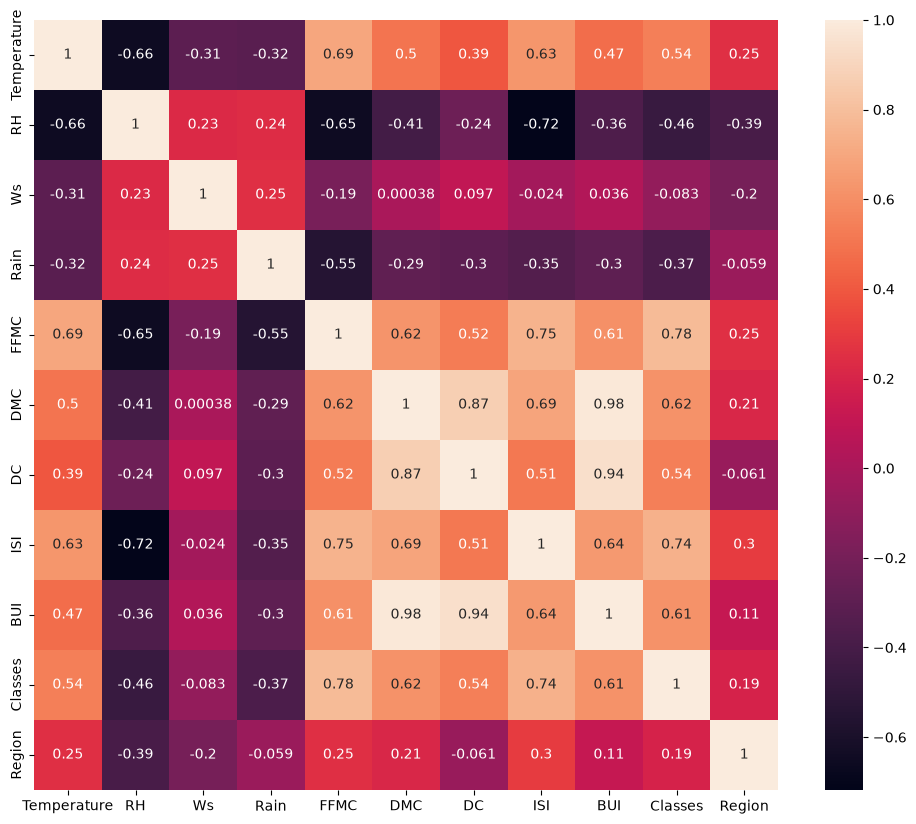

In [14]:
##Check for multicollinearity
import seaborn as sns
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [15]:
def correlation(dataset,threshold):
    col_corr=set() ##Here set beacuse i want only unique feature
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):##itereate throgh each and every feature
        for j in range(i):##compare along with other columns
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

In [16]:
##threshold===Domain expertise
corr_features=correlation(X_train,0.85)

In [17]:
##drop these feature when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape

(182, 9)

FEATURE SCALING

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [20]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

Text(0.5, 1.0, 'X_train after scaling')

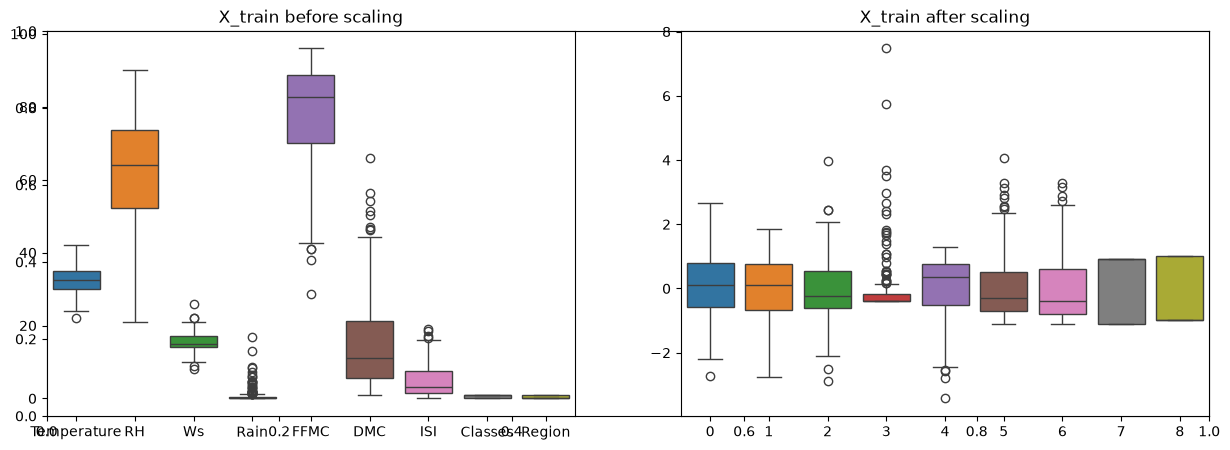

In [21]:
##boxplot to understand effect of standard scaler
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train after scaling')

LINEAR REGRESSION MODEL

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn import set_config

set_config(display='text')
reg=LinearRegression()
reg.fit(X_train_scaled,y_train)


LinearRegression()

In [23]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
y_pred=reg.predict(X_test_scaled)
from sklearn.metrics import r2_score

MAE: 0.5468236465249986
MSE: 0.6742766873791607
RMSE: 0.8211435242265268
R2 score 0.9847657384266951


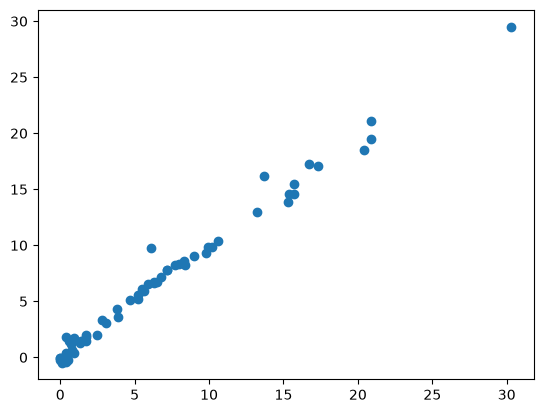

In [24]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
score=r2_score(y_test,y_pred)
print("R2 score",score)
plt.scatter(y_test,y_pred)

LASSO REGRESSION

MAE: 0.5642305340105692
MSE: 0.6949198918152074
RMSE: 0.8336185529456548
R2 score 0.9842993364555513


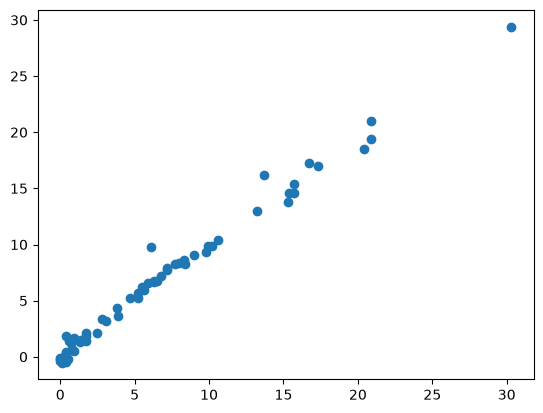

In [25]:
from sklearn.linear_model import Ridge
from sklearn import set_config

set_config(display='text')
reg=Ridge()
reg.fit(X_train_scaled,y_train)


from sklearn.metrics import mean_absolute_error,mean_squared_error
y_pred=reg.predict(X_test_scaled)
from sklearn.metrics import r2_score

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
score=r2_score(y_test,y_pred)
print("R2 score",score)
plt.scatter(y_test,y_pred)

In [26]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

In [27]:
lassocv.alpha_

np.float64(0.06582808719529475)

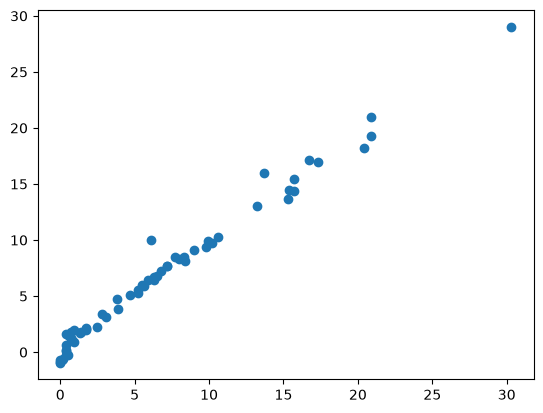

In [28]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)

In [29]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
score=r2_score(y_test,y_pred)
print(score)

MAE: 0.6358894638564663
MSE: 0.8214458563350046
RMSE: 0.9063365028150442
0.9814406737205228


RIDGE REGRESSION MODEL

MAE: 0.5642305340105692
MSE: 0.6949198918152074
RMSE: 0.8336185529456548
R2 score 0.9842993364555513


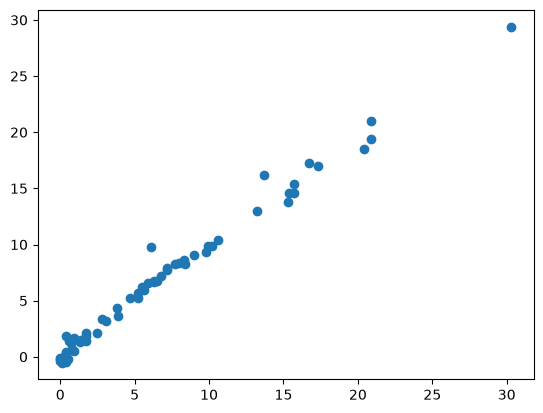

In [30]:
from sklearn.linear_model import Ridge
from sklearn import set_config
set_config(display='text')
reg=Ridge()
reg.fit(X_train_scaled,y_train)


from sklearn.metrics import mean_absolute_error,mean_squared_error
y_pred=reg.predict(X_test_scaled)
from sklearn.metrics import r2_score

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
score=r2_score(y_test,y_pred)
print("R2 score",score)
plt.scatter(y_test,y_pred)


0.9842993364555513
Mean Absolute Error: 0.5642305340105692


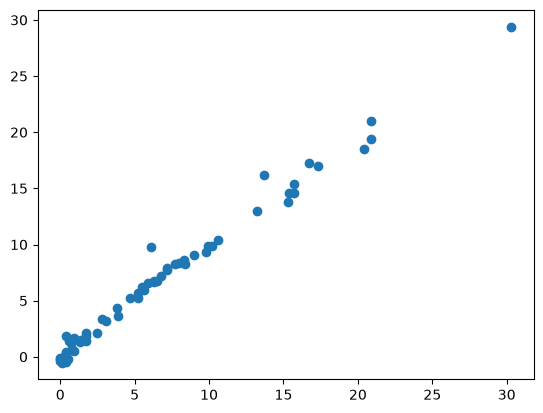

In [31]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(score)
print("Mean Absolute Error:",mae)

ELASTICNET REGRESSION

MAE: 1.8822353634895999
MSE: 5.517251101025223
RMSE: 2.3488829474933874
R2 score 0.8753460589519703


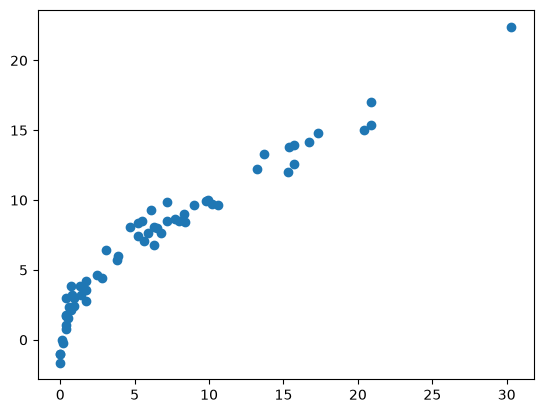

In [32]:
from sklearn.linear_model import ElasticNet
from sklearn import set_config
set_config(display='text')
reg=ElasticNet()
reg.fit(X_train_scaled,y_train)


from sklearn.metrics import mean_absolute_error,mean_squared_error
y_pred=reg.predict(X_test_scaled)
from sklearn.metrics import r2_score

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
score=r2_score(y_test,y_pred)
print("R2 score",score)
plt.scatter(y_test,y_pred)

In [33]:
# Save every model's predictions separately!
y_pred_linear = reg.predict(X_test_scaled)
y_pred_lasso = reg.predict(X_test_scaled)
y_pred_ridge = reg.predict(X_test_scaled)
y_pred_elastic = reg.predict(X_test_scaled)

# Now you can check any of them whenever you want without them overwriting each other
print(f"Ridge Score: {r2_score(y_test, y_pred_ridge)}")
print(f"Elastic Score: {r2_score(y_test, y_pred_elastic)}")

Ridge Score: 0.8753460589519703
Elastic Score: 0.8753460589519703


In [34]:
##pickle the machine leraning model,preprocessing
scaler

StandardScaler()

In [35]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(reg,open('ridge.pkl','wb'))